# Week 1 — Linear Regression

**Integrated Capstone Project: Breast Cancer (two datasets)**

### Notebook purpose
This notebook applies the Week 1 concepts — linear regression with polynomial terms, interaction terms, multicollinearity, the variance inflation factor (VIF), and categorical versus continuous features — to the **two breast cancer datasets** I use throughout my capstone:

1. **Breast Cancer Wisconsin (Diagnostic)** — tumor morphology measurements taken from images (radius, texture, perimeter, area, smoothness, concavity).
2. **Breast Cancer Coimbra** — clinical, anthropometric, and blood-based biomarkers (age, BMI, glucose, insulin, HOMA, leptin, adiponectin, resistin, MCP-1).

I analyze both datasets with the same Week 1 methods so I can compare how two very different kinds of healthcare data behave. I do not merge them, because they contain different patients and different variables. Instead I run a parallel analysis on each and compare the results at the end.

### Project question
> To what extent can measurable patient and tumor characteristics help distinguish breast cancer cases from non-cancer cases?

### A note on the modeling choice
Both outcomes are categorical (malignant/benign, or patient/control), so in this notebook I use **linear regression as an exploratory linear probability model**. This is not the final clinical model — later weeks use logistic regression, SVMs, decision trees, and random forests. For Week 1, linear regression is useful because it makes relationships, polynomial and interaction terms, and multicollinearity easy to demonstrate.

### Roadmap
- **Part 1** — Breast Cancer Wisconsin analysis
- **Part 2** — Breast Cancer Coimbra analysis
- **Part 3** — Comparison and overall Week 1 conclusions
- **References**

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Dataset
from sklearn.datasets import load_breast_cancer
# Modeling and preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, recall_score, precision_score
# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)


## Part 1 — Breast Cancer Wisconsin (Diagnostic)

This dataset is loaded from `sklearn.datasets.load_breast_cancer`. It contains tumor measurements computed from digitized images, with each tumor labeled benign or malignant. The notebook uses standard Python data science libraries (imported above).

### 1.1 Load and prepare the data

The original target variable is diagnosis. In the sklearn version, `0 = malignant` and `1 = benign`.  
For easier interpretation, this notebook creates:

- `diagnosis_malignant`: 1 if malignant, 0 if benign
- `diagnosis_label`: text label for plots and summaries

In [2]:
# Load the Breast Cancer Wisconsin Diagnostic dataset
cancer = load_breast_cancer()
#Create dataframe
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
# Clean column names for easier coding
df.columns = df.columns.str.replace(" ", "_")
# Create target columns
df["diagnosis_malignant"] = (cancer.target == 0).astype(int)
df["diagnosis_label"] = np.where(df["diagnosis_malignant"] == 1, "Malignant", "Benign")
print("Dataset shape:", df.shape)
print("\nDiagnosis counts:")
print(df["diagnosis_label"].value_counts())
df.head()


Dataset shape: (569, 32)

Diagnosis counts:
diagnosis_label
Benign       357
Malignant    212
Name: count, dtype: int64


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,diagnosis_malignant,diagnosis_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1,Malignant


### 1.2 Categorical and continuous features

This dataset is mostly numerical. The tumor measurements, such as `mean_radius`, `mean_texture`, and `mean_area`, are **continuous features**.

The diagnosis label is categorical. To demonstrate categorical predictors in this week, I also create a derived categorical feature called `radius_group`, which groups tumors into small, medium, and large radius groups based on the distribution of `mean_radius`.

This step is mainly for learning purposes because the original Wisconsin dataset does not contain many categorical predictor variables.

In [3]:
# Continuous features selected for Week 1 analysis
continuous_features = [
    "mean_radius",
    "mean_perimeter",
    "mean_area",
    "mean_texture",
    "mean_smoothness",
    "mean_concavity"
]
# A smaller set that avoids the most obvious size-variable redundancy
reduced_features = [
    "mean_radius",
    "mean_texture",
    "mean_smoothness",
    "mean_concavity"
]
# Create a categorical feature from a continuous variable
df["radius_group"] = pd.qcut(
    df["mean_radius"],
    q=3,
    labels=["small", "medium", "large"]
)

print("Continuous features used:")
print(continuous_features)
print("\nCategorical feature created:")
print(df["radius_group"].value_counts())


Continuous features used:
['mean_radius', 'mean_perimeter', 'mean_area', 'mean_texture', 'mean_smoothness', 'mean_concavity']

Categorical feature created:
radius_group
small     191
large     190
medium    188
Name: count, dtype: int64


### 1.3 Exploratory analysis connected to modeling

Before modeling, I examine the relationship between tumor features and diagnosis. This connects this week's regression work to earlier EDA findings.

In [4]:
# Summary of selected continuous features by diagnosis
eda_summary = df.groupby("diagnosis_label")[continuous_features].mean().T
eda_summary


diagnosis_label,Benign,Malignant
mean_radius,12.146524,17.462830
mean_perimeter,78.075406,115.365377
mean_area,462.790196,978.376415
mean_texture,17.914762,21.604906
mean_smoothness,0.092478,0.102898
mean_concavity,0.046058,0.160775


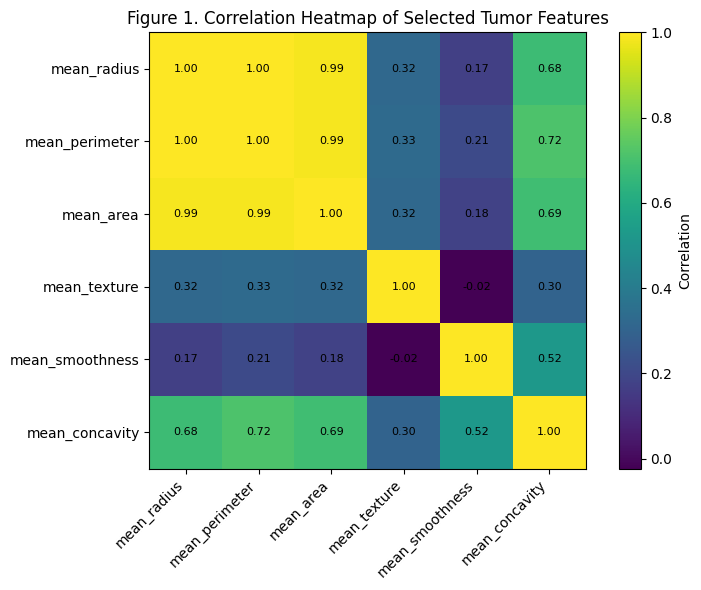

In [5]:
# Figure 1: Correlation heatmap for selected tumor features
corr = df[continuous_features].corr()
plt.figure(figsize=(8, 6))
plt.imshow(corr)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Figure 1. Correlation Heatmap of Selected Tumor Features")
# Add correlation values to the heatmap
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.tight_layout()
plt.show()


#### EDA interpretation

The heatmap is important for Week 1 because linear regression can be affected by multicollinearity. If variables such as `mean_radius`, `mean_perimeter`, and `mean_area` are highly correlated, their individual regression coefficients can become unstable even if the overall prediction is still strong.

### 1.4 Train-test split

The train-test split is used to reduce overfitting risk. The model is trained on one portion of the data and evaluated on a separate test set.

In [6]:
# Target variable
y = df["diagnosis_malignant"]
# Main feature sets
X_full = df[continuous_features]
X_reduced = df[reduced_features]
# Stratify keeps the benign/malignant proportions similar in train and test sets
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train_reduced = X_train_full[reduced_features]
X_test_reduced = X_test_full[reduced_features]
print("Training set size:", X_train_full.shape)
print("Test set size:", X_test_full.shape)
print("\nTraining diagnosis proportion:")
print(y_train.value_counts(normalize=True))
print("\nTest diagnosis proportion:")
print(y_test.value_counts(normalize=True))


Training set size: (455, 6)
Test set size: (114, 6)

Training diagnosis proportion:
diagnosis_malignant
0    0.626374
1    0.373626
Name: proportion, dtype: float64

Test diagnosis proportion:
diagnosis_malignant
0    0.631579
1    0.368421
Name: proportion, dtype: float64


### 1.5 Model-evaluation helper

Since the target is 0/1, the linear regression predictions are interpreted as approximate predicted probabilities. Predictions are clipped between 0 and 1 for easier interpretation.

Metrics used:

- **RMSE:** average size of prediction error, with larger errors penalized more
- **MAE:** average absolute prediction error
- **R²:** amount of variation explained by the model
- **Accuracy, recall, precision at threshold 0.5:** classification-style checks only, not the main linear regression metric

In this medical context, **recall for malignant cases** is especially important because false negatives are clinically concerning.

In [7]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    """Fit a model and return regression + classification-style metrics."""
    model.fit(X_train, y_train)
    train_pred = np.clip(model.predict(X_train), 0, 1)
    test_pred = np.clip(model.predict(X_test), 0, 1)
    test_class = (test_pred >= 0.50).astype(int)
    results = {
        "model": name,
        "train_RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
        "test_RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
        "train_MAE": mean_absolute_error(y_train, train_pred),
        "test_MAE": mean_absolute_error(y_test, test_pred),
        "train_R2": r2_score(y_train, train_pred),
        "test_R2": r2_score(y_test, test_pred),
        "accuracy_at_0.5": accuracy_score(y_test, test_class),
        "recall_malignant_at_0.5": recall_score(y_test, test_class, pos_label=1),
        "precision_malignant_at_0.5": precision_score(y_test, test_class, pos_label=1)
    }

    return results, train_pred, test_pred


### 1.6 Baseline linear regression

This first model uses continuous tumor features only. Standardization is included because features are on very different scales. For example, tumor area has much larger numeric values than smoothness.

In [8]:
baseline_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("linear_regression", LinearRegression())
])
baseline_results, baseline_train_pred, baseline_test_pred = evaluate_model(
    "Baseline linear regression: full continuous features",
    baseline_model,
    X_train_full,
    X_test_full,
    y_train,
    y_test
)
pd.DataFrame([baseline_results])


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_malignant_at_0.5,precision_malignant_at_0.5
0,Baseline linear regression: full continuous fe...,0.260167,0.27349,0.190353,0.200448,0.710776,0.678553,0.912281,0.833333,0.921053


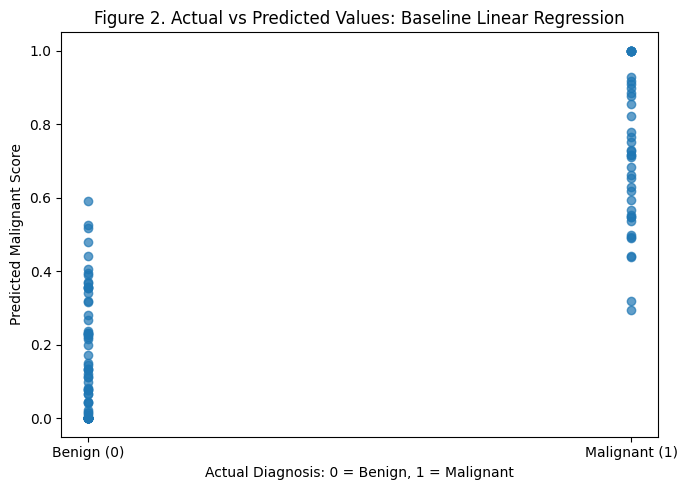

In [9]:
# Figure 2: Actual vs predicted values for baseline model
plt.figure(figsize=(7, 5))
plt.scatter(y_test, baseline_test_pred, alpha=0.7)
plt.xlabel("Actual Diagnosis: 0 = Benign, 1 = Malignant")
plt.ylabel("Predicted Malignant Score")
plt.title("Figure 2. Actual vs Predicted Values: Baseline Linear Regression")
plt.xticks([0, 1], ["Benign (0)", "Malignant (1)"])
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()


### 1.7 Multicollinearity and the variance inflation factor (VIF)

VIF measures how strongly one predictor can be explained by the other predictors. A high VIF suggests multicollinearity.

Common interpretation:
- VIF close to 1: low multicollinearity
- VIF above 5: possible concern
- VIF above 10: strong concern

Because radius, perimeter, and area all describe tumor size, I expect high VIF values among these variables.

In [10]:
def calculate_vif(X):
    """Calculate VIF manually using linear regression.

    For each feature, regress that feature on all other features.
    VIF = 1 / (1 - R²)
    """
    vif_data = []
    for feature in X.columns:
        y_feature = X[feature]
        X_other = X.drop(columns=[feature])
        model = LinearRegression()
        model.fit(X_other, y_feature)
        r_squared = model.score(X_other, y_feature)
        if r_squared >= 0.999999:
            vif = np.inf
        else:
            vif = 1 / (1 - r_squared)
        vif_data.append({
            "feature": feature,
            "R_squared_with_other_predictors": r_squared,
            "VIF": vif
        })
    return pd.DataFrame(vif_data).sort_values("VIF", ascending=False)
vif_full = calculate_vif(df[continuous_features])
vif_full


,feature,R_squared_with_other_predictors,VIF
1,mean_perimeter,0.998855,873.476620
0,mean_radius,0.998794,829.419705
2,mean_area,0.975498,40.812258
5,mean_concavity,0.854029,6.850699
4,mean_smoothness,0.392038,1.644838
3,mean_texture,0.149803,1.176198


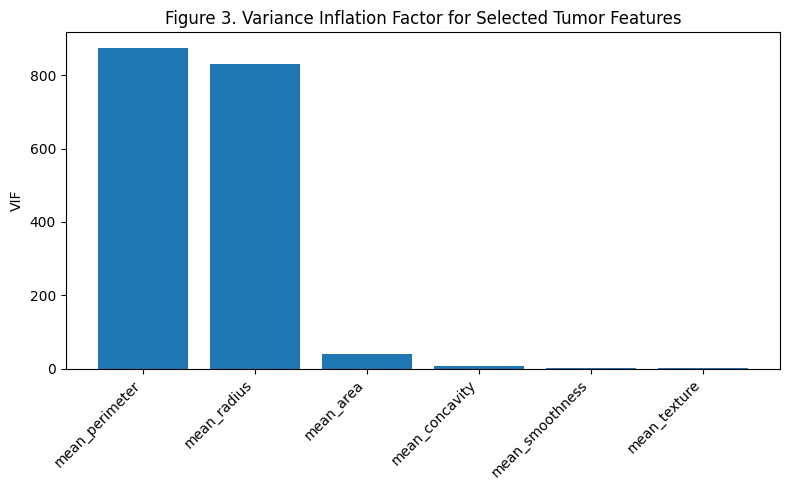

In [11]:
# Figure 3: VIF values for selected features
plt.figure(figsize=(8, 5))
plt.bar(vif_full["feature"], vif_full["VIF"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("VIF")
plt.title("Figure 3. Variance Inflation Factor for Selected Tumor Features")
plt.tight_layout()
plt.show()


#### VIF interpretation

If `mean_radius`, `mean_perimeter`, and `mean_area` show very high VIF values, this supports the EDA finding that many size-related variables are measuring the same underlying concept. This does not mean the variables are useless, but it does mean their individual regression coefficients should be interpreted carefully.

### 1.8 Reduced model after addressing multicollinearity

To reduce multicollinearity, I remove `mean_perimeter` and `mean_area` and keep `mean_radius` as the main tumor size variable. This helps test whether a simpler model can perform nearly as well while being easier to interpret.

In [12]:
vif_reduced = calculate_vif(df[reduced_features])
vif_reduced


,feature,R_squared_with_other_predictors,VIF
3,mean_concavity,0.643433,2.804522
0,mean_radius,0.510153,2.041455
2,mean_smoothness,0.356602,1.554247
1,mean_texture,0.147530,1.173062


In [13]:
reduced_linear_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("linear_regression", LinearRegression())
])
reduced_results, reduced_train_pred, reduced_test_pred = evaluate_model(
    "Reduced linear regression: lower multicollinearity",
    reduced_linear_model,
    X_train_reduced,
    X_test_reduced,
    y_train,
    y_test
)
pd.DataFrame([baseline_results, reduced_results])


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_malignant_at_0.5,precision_malignant_at_0.5
0,Baseline linear regression: full continuous fe...,0.260167,0.273490,0.190353,0.200448,0.710776,0.678553,0.912281,0.833333,0.921053
1,Reduced linear regression: lower multicollinea...,0.265908,0.278903,0.196652,0.206774,0.697871,0.665701,0.903509,0.785714,0.942857


### 1.9 Polynomial terms

Polynomial terms allow linear regression to model curved relationships. For example, the association between tumor radius and malignancy may not increase at the same rate across all radius values.

This model uses degree 2 polynomial terms on the reduced feature set. Degree 2 includes squared terms such as:

- `mean_radius²`
- `mean_texture²`
- `mean_smoothness²`
- `mean_concavity²`

It also includes interaction terms automatically, but the next section isolates interaction terms more directly.

In [14]:
polynomial_model = Pipeline(steps=[
    ("polynomial_features", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("linear_regression", LinearRegression())
])
poly_results, poly_train_pred, poly_test_pred = evaluate_model(
    "Polynomial regression: degree 2 on reduced features",
    polynomial_model,
    X_train_reduced,
    X_test_reduced,
    y_train,
    y_test
)
pd.DataFrame([baseline_results, reduced_results, poly_results])


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_malignant_at_0.5,precision_malignant_at_0.5
0,Baseline linear regression: full continuous fe...,0.260167,0.273490,0.190353,0.200448,0.710776,0.678553,0.912281,0.833333,0.921053
1,Reduced linear regression: lower multicollinea...,0.265908,0.278903,0.196652,0.206774,0.697871,0.665701,0.903509,0.785714,0.942857
2,Polynomial regression: degree 2 on reduced fea...,0.232386,0.241620,0.159488,0.170100,0.769246,0.749105,0.964912,0.928571,0.975000


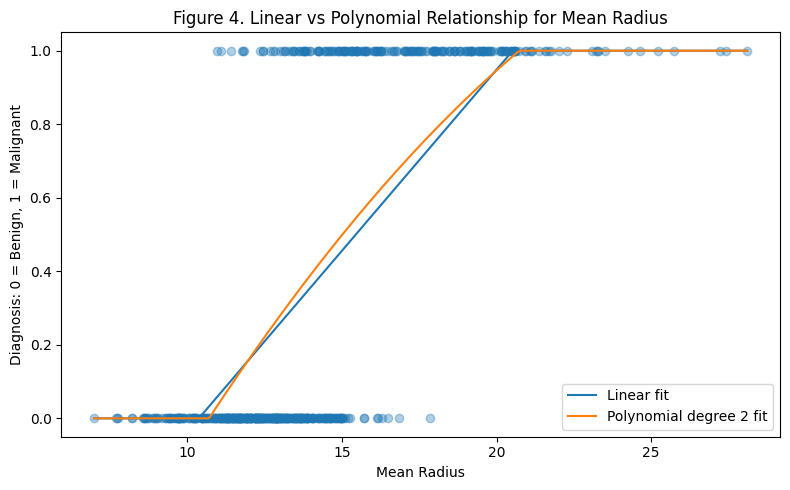

In [15]:
# Figure 4: Example polynomial relationship using mean_radius only

# Single-feature data for visualization
X_radius = df[["mean_radius"]]
y_radius = df["diagnosis_malignant"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_radius,
    y_radius,
    test_size=0.20,
    random_state=42,
    stratify=y_radius
)
radius_linear = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("linear_regression", LinearRegression())
])
radius_poly = Pipeline(steps=[
    ("polynomial_features", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("linear_regression", LinearRegression())
])
radius_linear.fit(Xr_train, yr_train)
radius_poly.fit(Xr_train, yr_train)
radius_grid = pd.DataFrame({
    "mean_radius": np.linspace(df["mean_radius"].min(), df["mean_radius"].max(), 200)
})
linear_curve = np.clip(radius_linear.predict(radius_grid), 0, 1)
poly_curve = np.clip(radius_poly.predict(radius_grid), 0, 1)
plt.figure(figsize=(8, 5))
plt.scatter(df["mean_radius"], df["diagnosis_malignant"], alpha=0.35)
plt.plot(radius_grid["mean_radius"], linear_curve, label="Linear fit")
plt.plot(radius_grid["mean_radius"], poly_curve, label="Polynomial degree 2 fit")
plt.xlabel("Mean Radius")
plt.ylabel("Diagnosis: 0 = Benign, 1 = Malignant")
plt.title("Figure 4. Linear vs Polynomial Relationship for Mean Radius")
plt.legend()
plt.tight_layout()
plt.show()


### 1.10 Interaction terms

Interaction terms test whether the effect of one feature depends on another feature. For example, the relationship between radius and malignancy may depend on concavity or texture.

This model uses interaction-only polynomial features. It includes terms such as:

- `mean_radius × mean_texture`
- `mean_radius × mean_concavity`
- `mean_texture × mean_concavity`

It does not include squared terms.

In [16]:
interaction_model = Pipeline(steps=[
    ("interaction_features", PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)),
    ("scaler", StandardScaler()),
    ("linear_regression", LinearRegression())
])
interaction_results, interaction_train_pred, interaction_test_pred = evaluate_model(
    "Interaction-only linear regression",
    interaction_model,
    X_train_reduced,
    X_test_reduced,
    y_train,
    y_test
)
pd.DataFrame([baseline_results, reduced_results, poly_results, interaction_results])


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_malignant_at_0.5,precision_malignant_at_0.5
0,Baseline linear regression: full continuous fe...,0.260167,0.273490,0.190353,0.200448,0.710776,0.678553,0.912281,0.833333,0.921053
1,Reduced linear regression: lower multicollinea...,0.265908,0.278903,0.196652,0.206774,0.697871,0.665701,0.903509,0.785714,0.942857
2,Polynomial regression: degree 2 on reduced fea...,0.232386,0.241620,0.159488,0.170100,0.769246,0.749105,0.964912,0.928571,0.975000
3,Interaction-only linear regression,0.250995,0.262583,0.177080,0.189324,0.730811,0.703681,0.921053,0.857143,0.923077


### 1.11 Categorical and continuous features together

The Wisconsin dataset is primarily numerical, so I created `radius_group` to demonstrate how categorical variables can be used in regression. The model includes:

- Continuous features: `mean_texture`, `mean_smoothness`, `mean_concavity`
- Categorical feature: `radius_group`

The categorical feature is one-hot encoded.

In [17]:
categorical_features = ["radius_group"]
continuous_features_for_cat_model = ["mean_texture", "mean_smoothness", "mean_concavity"]
X_cat = df[categorical_features + continuous_features_for_cat_model]
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_cat,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
preprocessor = ColumnTransformer(transformers=[
    ("continuous", StandardScaler(), continuous_features_for_cat_model),
    ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
])
cat_cont_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("linear_regression", LinearRegression())
])
cat_cont_results, cat_train_pred, cat_test_pred = evaluate_model(
    "Categorical + continuous linear regression",
    cat_cont_model,
    X_train_cat,
    X_test_cat,
    y_train_cat,
    y_test_cat
)
pd.DataFrame([
    baseline_results,
    reduced_results,
    poly_results,
    interaction_results,
    cat_cont_results
])


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_malignant_at_0.5,precision_malignant_at_0.5
0,Baseline linear regression: full continuous fe...,0.260167,0.273490,0.190353,0.200448,0.710776,0.678553,0.912281,0.833333,0.921053
1,Reduced linear regression: lower multicollinea...,0.265908,0.278903,0.196652,0.206774,0.697871,0.665701,0.903509,0.785714,0.942857
2,Polynomial regression: degree 2 on reduced fea...,0.232386,0.241620,0.159488,0.170100,0.769246,0.749105,0.964912,0.928571,0.975000
3,Interaction-only linear regression,0.250995,0.262583,0.177080,0.189324,0.730811,0.703681,0.921053,0.857143,0.923077
4,Categorical + continuous linear regression,0.252464,0.287049,0.159886,0.189169,0.727650,0.645888,0.877193,0.785714,0.868421


### 1.12 Cross-validation and model comparison

Cross-validation helps reduce overfitting concerns because performance is averaged across multiple train/test splits instead of relying on one split only.

For this notebook, the main model-comparison metric is **cross-validated RMSE**. Lower RMSE means the model's predicted malignant score is closer to the true 0/1 outcome.

In [18]:
def cross_validated_rmse(model, X, y, n_splits=5):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    # Use negative MSE, then convert to positive RMSE
    mse_scores = -cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="neg_mean_squared_error"
    )
    rmse_scores = np.sqrt(mse_scores)
    return rmse_scores.mean(), rmse_scores.std()
model_specs = [
    ("Baseline full linear", baseline_model, X_full),
    ("Reduced linear", reduced_linear_model, X_reduced),
    ("Polynomial degree 2", polynomial_model, X_reduced),
    ("Interaction-only", interaction_model, X_reduced),
    ("Categorical + continuous", cat_cont_model, X_cat)
]
cv_results = []
for name, model, X_model in model_specs:
    mean_rmse, std_rmse = cross_validated_rmse(model, X_model, y)
    cv_results.append({
        "model": name,
        "CV_RMSE_mean": mean_rmse,
        "CV_RMSE_std": std_rmse
    })
cv_results_df = pd.DataFrame(cv_results).sort_values("CV_RMSE_mean")
cv_results_df


,model,CV_RMSE_mean,CV_RMSE_std
2,Polynomial degree 2,0.259535,0.014724
4,Categorical + continuous,0.269200,0.008068
3,Interaction-only,0.278105,0.021138
0,Baseline full linear,0.282847,0.013374
1,Reduced linear,0.289294,0.015249


In [19]:
# Combine test-set metrics and cross-validation results
test_results_df = pd.DataFrame([
    baseline_results,
    reduced_results,
    poly_results,
    interaction_results,
    cat_cont_results
])
summary_df = test_results_df.merge(
    cv_results_df,
    left_on="model",
    right_on="model",
    how="left"
)
summary_df.sort_values("CV_RMSE_mean")


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_malignant_at_0.5,precision_malignant_at_0.5,CV_RMSE_mean,CV_RMSE_std
0,Baseline linear regression: full continuous fe...,0.260167,0.273490,0.190353,0.200448,0.710776,0.678553,0.912281,0.833333,0.921053,NaN,NaN
1,Reduced linear regression: lower multicollinea...,0.265908,0.278903,0.196652,0.206774,0.697871,0.665701,0.903509,0.785714,0.942857,NaN,NaN
2,Polynomial regression: degree 2 on reduced fea...,0.232386,0.241620,0.159488,0.170100,0.769246,0.749105,0.964912,0.928571,0.975000,NaN,NaN
3,Interaction-only linear regression,0.250995,0.262583,0.177080,0.189324,0.730811,0.703681,0.921053,0.857143,0.923077,NaN,NaN
4,Categorical + continuous linear regression,0.252464,0.287049,0.159886,0.189169,0.727650,0.645888,0.877193,0.785714,0.868421,NaN,NaN


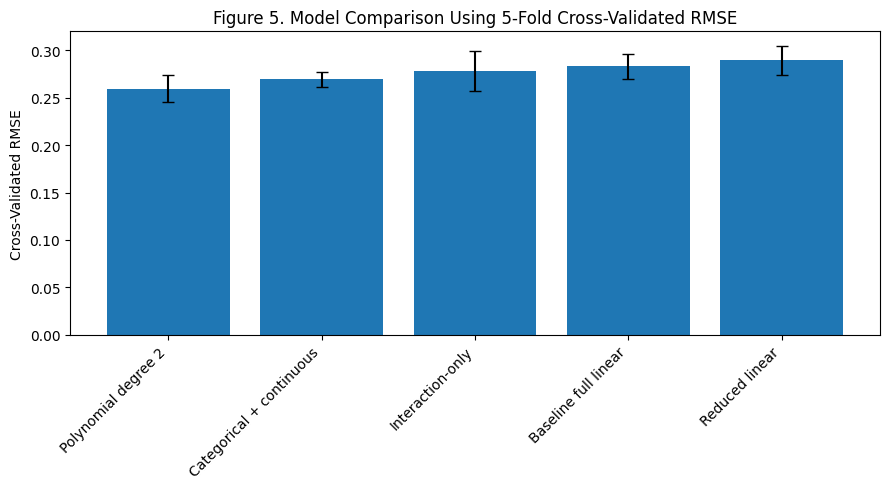

In [20]:
# Figure 5: Cross-validated RMSE comparison
plot_df = cv_results_df.sort_values("CV_RMSE_mean")
plt.figure(figsize=(9, 5))
plt.bar(plot_df["model"], plot_df["CV_RMSE_mean"], yerr=plot_df["CV_RMSE_std"], capsize=4)
plt.ylabel("Cross-Validated RMSE")
plt.title("Figure 5. Model Comparison Using 5-Fold Cross-Validated RMSE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 1.13 Part 1 summary: Wisconsin

After running the Wisconsin analysis, I found that several tumor features are strongly related to whether a tumor is benign or malignant. Features such as `mean_radius`, `mean_perimeter`, `mean_area`, and `mean_concavity` tended to be higher for malignant tumors. This matches what I expected based on my earlier exploratory data analysis, where larger tumor measurements seemed to be associated with malignant diagnosis.

One important finding was the presence of multicollinearity. The VIF results showed that `mean_radius`, `mean_perimeter`, and `mean_area` were highly related to each other. This makes sense because all three variables describe tumor size in slightly different ways. Even though these features are useful for prediction, they may not all need to be included together in a linear regression model because they are measuring a similar underlying concept.

Because of this, I created a reduced model by removing `mean_perimeter` and `mean_area` while keeping `mean_radius` as the main size-related feature. This made the model easier to interpret and helped reduce multicollinearity. If the reduced model performs close to the full model, then it may be a better option because it is simpler and avoids using several highly redundant predictors.

I also tested polynomial terms to see whether nonlinear relationships improved the model. This was useful because the relationship between tumor measurements and malignancy may not be perfectly straight-line. For example, the risk of malignancy may increase more sharply once tumor size reaches a certain range. The polynomial model allowed the regression to capture more flexible patterns in the data.

Interaction terms were also helpful to explore. They allowed me to test whether the effect of one tumor feature depended on another feature. For example, a larger radius may be more concerning when concavity is also high. This is important because diagnosis is likely influenced by a combination of tumor characteristics rather than one feature alone.

I also included a categorical feature by creating `radius_group`, which grouped tumors into small, medium, and large radius categories. This helped demonstrate how categorical and continuous features can be used together in a regression model. Since the original Wisconsin dataset is mostly numerical, this was a useful way to practice encoding categorical variables.

To reduce overfitting, I used a train-test split, stratified the split by diagnosis, compared training and testing errors, and used cross-validation. I also compared several models instead of relying on only one. These steps helped me see whether the models were generalizing well or just fitting the training data too closely.

Overall, the results were mostly expected. Tumor size-related features were strongly associated with diagnosis. However, what stood out most was how much overlap existed among the size-related variables. This showed me that a model can appear to use many predictors, but those predictors may actually represent the same general idea. In this case, many important features were connected to tumor size. This finding is important because it affects how I interpret the regression coefficients and how I decide which features to keep in future models.

## Part 2 — Breast Cancer Coimbra

The second dataset in my capstone is the **Breast Cancer Coimbra** dataset. It is also about breast cancer, but it uses a different kind of healthcare data than Wisconsin. Instead of tumor image measurements, it uses clinical, anthropometric, and blood-based predictors such as age, BMI, glucose, insulin, HOMA, leptin, adiponectin, resistin, and MCP-1.

I do not merge Wisconsin and Coimbra, because they do not share the same patients or the same variables. I run the same Week 1 methods on each dataset separately and compare them in Part 3. Using two different kinds of data side by side lets me see whether the same modeling ideas behave differently on tumor-image data versus routine clinical and blood-marker data.

### 2.1 Load and prepare the data

The Coimbra dataset target is called `Classification`.

According to the dataset documentation:

- `1 = Healthy controls`
- `2 = Patients with breast cancer`

For consistency with my Wisconsin analysis, I create:

- `breast_cancer_present = 1` for patients with breast cancer
- `breast_cancer_present = 0` for healthy controls

In [21]:
# Load the Breast Cancer Coimbra dataset from UCI
# This direct CSV link is commonly used for this UCI dataset.
coimbra_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00451/dataR2.csv"

coimbra_df = pd.read_csv(coimbra_url)

# Clean column names
coimbra_df.columns = (
    coimbra_df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace(".", "_", regex=False)
)

# Create binary target: 1 = breast cancer patient, 0 = healthy control
coimbra_df["breast_cancer_present"] = (coimbra_df["Classification"] == 2).astype(int)
coimbra_df["diagnosis_group"] = np.where(coimbra_df["breast_cancer_present"] == 1, "Patient", "Healthy Control")

print("Coimbra dataset shape:", coimbra_df.shape)
print("Class counts:")
print(coimbra_df["diagnosis_group"].value_counts())

print("Missing values:")
print(coimbra_df.isna().sum())

coimbra_df.head()


Coimbra dataset shape: (116, 12)
Class counts:
diagnosis_group
Patient            64
Healthy Control    52
Name: count, dtype: int64
Missing values:
Age                      0
BMI                      0
Glucose                  0
Insulin                  0
HOMA                     0
Leptin                   0
Adiponectin              0
Resistin                 0
MCP_1                    0
Classification           0
breast_cancer_present    0
diagnosis_group          0
dtype: int64


,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP_1,Classification,breast_cancer_present,diagnosis_group
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,1,0,Healthy Control
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,1,0,Healthy Control
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,1,0,Healthy Control
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,1,0,Healthy Control
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,1,0,Healthy Control


### 2.2 Exploratory analysis

The Coimbra dataset is much smaller than the Wisconsin dataset, but it is clean and has no missing values. All of the predictors are quantitative, so this dataset works well for regression-style practice.

The main predictors are clinical and blood-based features. This lets me compare a clinical biomarker dataset with the Wisconsin tumor morphology dataset.

In [22]:
# Define Coimbra features and target
coimbra_target = "breast_cancer_present"
coimbra_label = "diagnosis_group"

coimbra_features = [
    col for col in coimbra_df.columns
    if col not in ["Classification", coimbra_target, coimbra_label]
]

X_coimbra = coimbra_df[coimbra_features]
y_coimbra = coimbra_df[coimbra_target]

print("Coimbra features:")
print(coimbra_features)

print("Number of rows:", X_coimbra.shape[0])
print("Number of features:", X_coimbra.shape[1])


Coimbra features:
['Age', 'BMI', 'Glucose', 'Insulin', 'HOMA', 'Leptin', 'Adiponectin', 'Resistin', 'MCP_1']
Number of rows: 116
Number of features: 9


In [23]:
# Summary of Coimbra feature means by diagnosis group
coimbra_summary = coimbra_df.groupby("diagnosis_group")[coimbra_features].mean().T
coimbra_summary


diagnosis_group,Healthy Control,Patient
Age,58.076923,56.671875
BMI,28.317336,26.984740
Glucose,88.230769,105.562500
Insulin,6.933769,12.513219
HOMA,1.552398,3.623342
Leptin,26.637933,26.596512
Adiponectin,10.328205,10.061167
Resistin,11.614813,17.253777
MCP_1,499.730692,563.016500


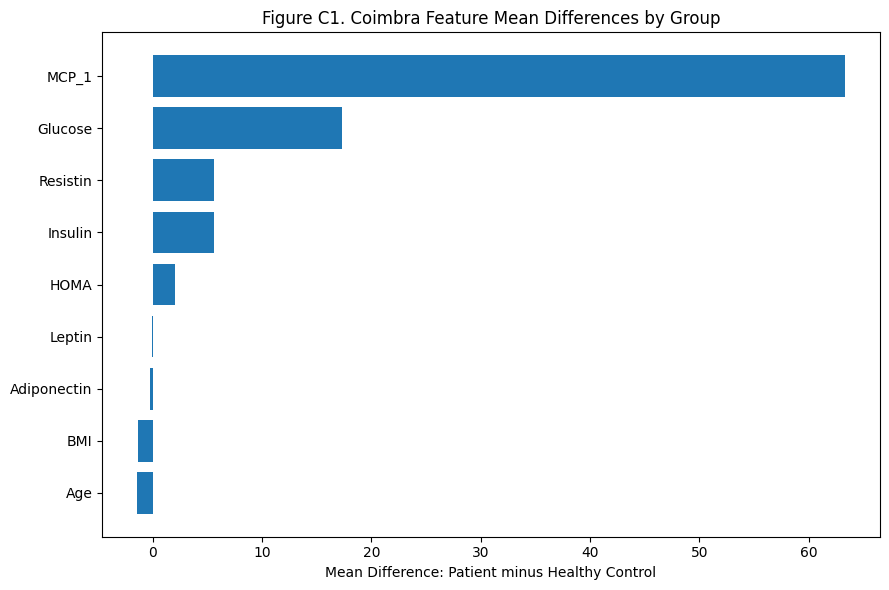

diagnosis_group,Healthy Control,Patient,difference_patient_minus_control
Age,58.076923,56.671875,-1.405048
BMI,28.317336,26.984740,-1.332596
Adiponectin,10.328205,10.061167,-0.267038
Leptin,26.637933,26.596512,-0.041420
HOMA,1.552398,3.623342,2.070944
Insulin,6.933769,12.513219,5.579450
Resistin,11.614813,17.253777,5.638964
Glucose,88.230769,105.562500,17.331731
MCP_1,499.730692,563.016500,63.285808


In [24]:
# Figure C1: Feature means by group for Coimbra dataset
coimbra_summary_plot = coimbra_summary.copy()
coimbra_summary_plot["difference_patient_minus_control"] = (
    coimbra_summary_plot["Patient"] - coimbra_summary_plot["Healthy Control"]
)

coimbra_summary_plot = coimbra_summary_plot.sort_values("difference_patient_minus_control")

plt.figure(figsize=(9, 6))
plt.barh(coimbra_summary_plot.index, coimbra_summary_plot["difference_patient_minus_control"])
plt.xlabel("Mean Difference: Patient minus Healthy Control")
plt.title("Figure C1. Coimbra Feature Mean Differences by Group")
plt.tight_layout()
plt.show()

coimbra_summary_plot


#### Coimbra EDA interpretation

This figure helps me see which clinical or blood-based variables differ the most between breast cancer patients and healthy controls. Unlike the Wisconsin dataset, these variables are not tumor image measurements. They represent routine clinical and blood markers, so the interpretation is different.

This is helpful for my capstone because I can compare two types of healthcare data:

- Wisconsin: tumor morphology data from images
- Coimbra: clinical and blood-based biomarker data

### 2.3 Correlation heatmap and multicollinearity

Just like I did for the Wisconsin dataset, I want to check whether the Coimbra predictors are highly correlated. This matters because multicollinearity can make linear regression coefficients harder to interpret.

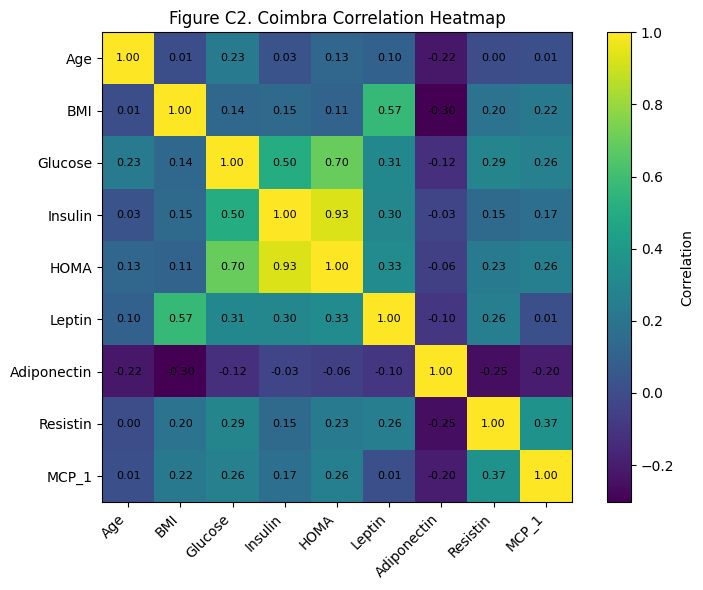

In [25]:
# Figure C2: Correlation heatmap for Coimbra predictors
coimbra_corr = coimbra_df[coimbra_features].corr()

plt.figure(figsize=(8, 6))
plt.imshow(coimbra_corr)
plt.colorbar(label="Correlation")
plt.xticks(range(len(coimbra_corr.columns)), coimbra_corr.columns, rotation=45, ha="right")
plt.yticks(range(len(coimbra_corr.columns)), coimbra_corr.columns)
plt.title("Figure C2. Coimbra Correlation Heatmap")

for i in range(len(coimbra_corr.columns)):
    for j in range(len(coimbra_corr.columns)):
        plt.text(j, i, f"{coimbra_corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()


### 2.4 VIF analysis

VIF helps me check whether predictors are redundant. This is especially useful because some blood-based predictors may be related to each other, such as glucose, insulin, and HOMA.

In [26]:
# VIF helper. It is defined in Part 1; this redefines it only if missing,
# so Part 2 can also be run on its own.
try:
    calculate_vif
except NameError:
    def calculate_vif(X):
        vif_data = []

        for feature in X.columns:
            y_feature = X[feature]
            X_other = X.drop(columns=[feature])

            model = LinearRegression()
            model.fit(X_other, y_feature)
            r_squared = model.score(X_other, y_feature)

            if r_squared >= 0.999999:
                vif = np.inf
            else:
                vif = 1 / (1 - r_squared)

            vif_data.append({
                "feature": feature,
                "R_squared_with_other_predictors": r_squared,
                "VIF": vif
            })

        return pd.DataFrame(vif_data).sort_values("VIF", ascending=False)

coimbra_vif = calculate_vif(X_coimbra)
coimbra_vif


,feature,R_squared_with_other_predictors,VIF
4,HOMA,0.945064,18.203099
3,Insulin,0.919688,12.451423
2,Glucose,0.659056,2.933032
5,Leptin,0.474182,1.901799
1,BMI,0.471480,1.892076
8,MCP_1,0.286542,1.401624
7,Resistin,0.258956,1.349447
6,Adiponectin,0.204958,1.257796
0,Age,0.146265,1.171323


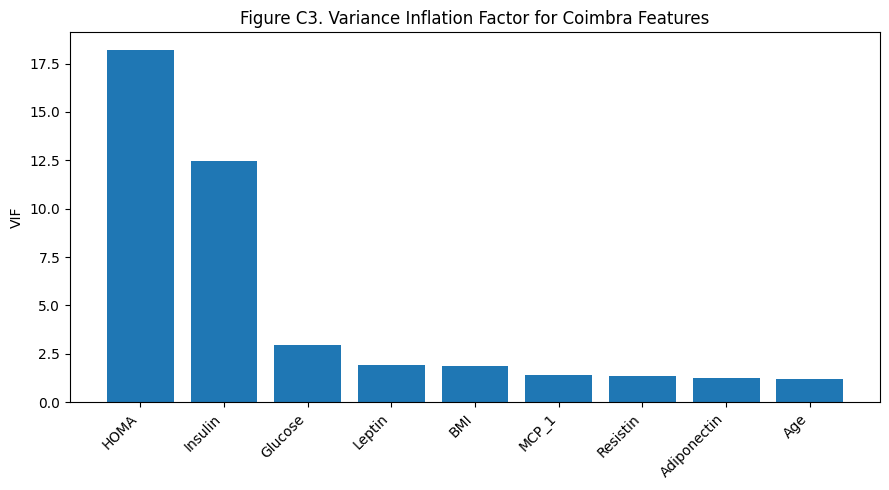

In [27]:
# Figure C3: Coimbra VIF values
plt.figure(figsize=(9, 5))
plt.bar(coimbra_vif["feature"], coimbra_vif["VIF"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("VIF")
plt.title("Figure C3. Variance Inflation Factor for Coimbra Features")
plt.tight_layout()
plt.show()


#### Coimbra VIF interpretation

If any Coimbra variables have high VIF values, this suggests that they overlap with other predictors. This does not automatically mean they should be removed, but it does mean I should be careful when interpreting individual regression coefficients.

For example, if glucose, insulin, and HOMA are related, then one variable's coefficient may change depending on whether the others are included.

### 2.5 Train-test split

I use a stratified train-test split again so both the training and test sets keep similar proportions of patients and healthy controls.

In [28]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_coimbra,
    y_coimbra,
    test_size=0.20,
    random_state=42,
    stratify=y_coimbra
)

print("Training shape:", X_train_c.shape)
print("Testing shape:", X_test_c.shape)

print("Training target distribution:")
print(y_train_c.value_counts(normalize=True).round(3))

print("Testing target distribution:")
print(y_test_c.value_counts(normalize=True).round(3))


Training shape: (92, 9)
Testing shape: (24, 9)
Training target distribution:
breast_cancer_present
1    0.554
0    0.446
Name: proportion, dtype: float64
Testing target distribution:
breast_cancer_present
1    0.542
0    0.458
Name: proportion, dtype: float64


### 2.6 Baseline linear regression

Since this is Week 1, I use linear regression as a linear probability model, similar to the Wisconsin section.

This is not the final model I would use clinically. It is mainly for practicing linear regression concepts with a binary outcome.

In [29]:
# Model-evaluation helper. Defined in Part 1; redefined here only if missing.
try:
    evaluate_model
except NameError:
    def evaluate_model(name, model, X_train, X_test, y_train, y_test):
        model.fit(X_train, y_train)

        train_pred = np.clip(model.predict(X_train), 0, 1)
        test_pred = np.clip(model.predict(X_test), 0, 1)

        test_class = (test_pred >= 0.50).astype(int)

        results = {
            "model": name,
            "train_RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
            "test_RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
            "train_MAE": mean_absolute_error(y_train, train_pred),
            "test_MAE": mean_absolute_error(y_test, test_pred),
            "train_R2": r2_score(y_train, train_pred),
            "test_R2": r2_score(y_test, test_pred),
            "accuracy_at_0.5": accuracy_score(y_test, test_class),
            "recall_positive_at_0.5": recall_score(y_test, test_class, pos_label=1),
            "precision_positive_at_0.5": precision_score(y_test, test_class, pos_label=1)
        }

        return results, train_pred, test_pred

coimbra_baseline_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("linear_regression", LinearRegression())
])

coimbra_baseline_results, coimbra_baseline_train_pred, coimbra_baseline_test_pred = evaluate_model(
    "Coimbra baseline linear regression",
    coimbra_baseline_model,
    X_train_c,
    X_test_c,
    y_train_c,
    y_test_c
)

pd.DataFrame([coimbra_baseline_results])


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_malignant_at_0.5,precision_malignant_at_0.5
0,Coimbra baseline linear regression,0.399587,0.46818,0.346577,0.40972,0.353685,0.117099,0.75,0.692308,0.818182


### 2.7 Polynomial terms

Polynomial terms allow me to test whether nonlinear relationships improve prediction.

For the Coimbra dataset, this is useful because clinical biomarkers may not have a perfectly straight-line relationship with breast cancer status. For example, the relationship between glucose, insulin, or resistin and the outcome may not be purely linear.

In [30]:
coimbra_poly_model = Pipeline(steps=[
    ("polynomial_features", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("linear_regression", LinearRegression())
])

coimbra_poly_results, coimbra_poly_train_pred, coimbra_poly_test_pred = evaluate_model(
    "Coimbra polynomial regression: degree 2",
    coimbra_poly_model,
    X_train_c,
    X_test_c,
    y_train_c,
    y_test_c
)

pd.DataFrame([coimbra_baseline_results, coimbra_poly_results])


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_malignant_at_0.5,precision_malignant_at_0.5
0,Coimbra baseline linear regression,0.399587,0.468180,0.346577,0.409720,0.353685,0.117099,0.75,0.692308,0.818182
1,Coimbra polynomial regression: degree 2,0.198146,0.489431,0.125741,0.373465,0.841074,0.035128,0.75,0.692308,0.818182


### 2.8 Interaction terms

Interaction terms help test whether the effect of one predictor depends on another predictor.

For this dataset, an example would be whether the relationship between glucose and breast cancer status changes depending on insulin or BMI. This is useful because clinical risk factors often work together instead of independently.

In [31]:
coimbra_interaction_model = Pipeline(steps=[
    ("interaction_features", PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)),
    ("scaler", StandardScaler()),
    ("linear_regression", LinearRegression())
])

coimbra_interaction_results, coimbra_interaction_train_pred, coimbra_interaction_test_pred = evaluate_model(
    "Coimbra interaction-only linear regression",
    coimbra_interaction_model,
    X_train_c,
    X_test_c,
    y_train_c,
    y_test_c
)

pd.DataFrame([
    coimbra_baseline_results,
    coimbra_poly_results,
    coimbra_interaction_results
])


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_malignant_at_0.5,precision_malignant_at_0.5
0,Coimbra baseline linear regression,0.399587,0.468180,0.346577,0.409720,0.353685,0.117099,0.75,0.692308,0.818182
1,Coimbra polynomial regression: degree 2,0.198146,0.489431,0.125741,0.373465,0.841074,0.035128,0.75,0.692308,0.818182
2,Coimbra interaction-only linear regression,0.260161,0.445159,0.179787,0.337254,0.726028,0.201792,0.75,0.692308,0.818182


### 2.9 Categorical and continuous features

The Coimbra dataset is mainly quantitative, so I create a simple categorical feature from BMI to practice using categorical and continuous features together.

This is similar to what I did in the Wisconsin dataset with `radius_group`.

Here I create:

- `BMI_group = lower BMI`
- `BMI_group = middle BMI`
- `BMI_group = higher BMI`

This is only for learning purposes. I am not saying these are official clinical BMI categories.

In [32]:
coimbra_df["BMI_group"] = pd.qcut(
    coimbra_df["BMI"],
    q=3,
    labels=["lower_BMI", "middle_BMI", "higher_BMI"]
)

coimbra_cat_features = ["BMI_group"]
coimbra_cont_features = [col for col in coimbra_features if col != "BMI"]

X_coimbra_cat = coimbra_df[coimbra_cat_features + coimbra_cont_features]
y_coimbra_cat = coimbra_df["breast_cancer_present"]

X_train_cat_c, X_test_cat_c, y_train_cat_c, y_test_cat_c = train_test_split(
    X_coimbra_cat,
    y_coimbra_cat,
    test_size=0.20,
    random_state=42,
    stratify=y_coimbra_cat
)

coimbra_preprocessor = ColumnTransformer(transformers=[
    ("continuous", StandardScaler(), coimbra_cont_features),
    ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), coimbra_cat_features)
])

coimbra_cat_model = Pipeline(steps=[
    ("preprocessor", coimbra_preprocessor),
    ("linear_regression", LinearRegression())
])

coimbra_cat_results, coimbra_cat_train_pred, coimbra_cat_test_pred = evaluate_model(
    "Coimbra categorical + continuous regression",
    coimbra_cat_model,
    X_train_cat_c,
    X_test_cat_c,
    y_train_cat_c,
    y_test_cat_c
)

pd.DataFrame([
    coimbra_baseline_results,
    coimbra_poly_results,
    coimbra_interaction_results,
    coimbra_cat_results
])


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_malignant_at_0.5,precision_malignant_at_0.5
0,Coimbra baseline linear regression,0.399587,0.468180,0.346577,0.409720,0.353685,0.117099,0.750,0.692308,0.818182
1,Coimbra polynomial regression: degree 2,0.198146,0.489431,0.125741,0.373465,0.841074,0.035128,0.750,0.692308,0.818182
2,Coimbra interaction-only linear regression,0.260161,0.445159,0.179787,0.337254,0.726028,0.201792,0.750,0.692308,0.818182
3,Coimbra categorical + continuous regression,0.392276,0.473737,0.336024,0.414795,0.377119,0.096015,0.625,0.538462,0.700000


### 2.10 Cross-validation model comparison

Because the Coimbra dataset is small, cross-validation is especially important. A single train-test split may be unstable with only 116 rows.

I compare the baseline, polynomial, interaction-only, and categorical/continuous models using cross-validated RMSE.

In [33]:
# Cross-validation helper. Defined in Part 1; redefined here only if missing.
try:
    cross_validated_rmse
except NameError:
    def cross_validated_rmse(model, X, y, n_splits=5):
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

        mse_scores = -cross_val_score(
            model,
            X,
            y,
            cv=cv,
            scoring="neg_mean_squared_error"
        )

        rmse_scores = np.sqrt(mse_scores)

        return rmse_scores.mean(), rmse_scores.std()

coimbra_model_specs = [
    ("Coimbra baseline linear", coimbra_baseline_model, X_coimbra),
    ("Coimbra polynomial degree 2", coimbra_poly_model, X_coimbra),
    ("Coimbra interaction-only", coimbra_interaction_model, X_coimbra),
    ("Coimbra categorical + continuous", coimbra_cat_model, X_coimbra_cat)
]

coimbra_cv_results = []

for name, model, X_model in coimbra_model_specs:
    mean_rmse, std_rmse = cross_validated_rmse(model, X_model, y_coimbra, n_splits=5)
    coimbra_cv_results.append({
        "model": name,
        "CV_RMSE_mean": mean_rmse,
        "CV_RMSE_std": std_rmse
    })

coimbra_cv_results_df = pd.DataFrame(coimbra_cv_results).sort_values("CV_RMSE_mean")
coimbra_cv_results_df


,model,CV_RMSE_mean,CV_RMSE_std
3,Coimbra categorical + continuous,0.466505,0.068473
0,Coimbra baseline linear,0.471838,0.069570
2,Coimbra interaction-only,1.380313,1.009830
1,Coimbra polynomial degree 2,7.364395,12.419363


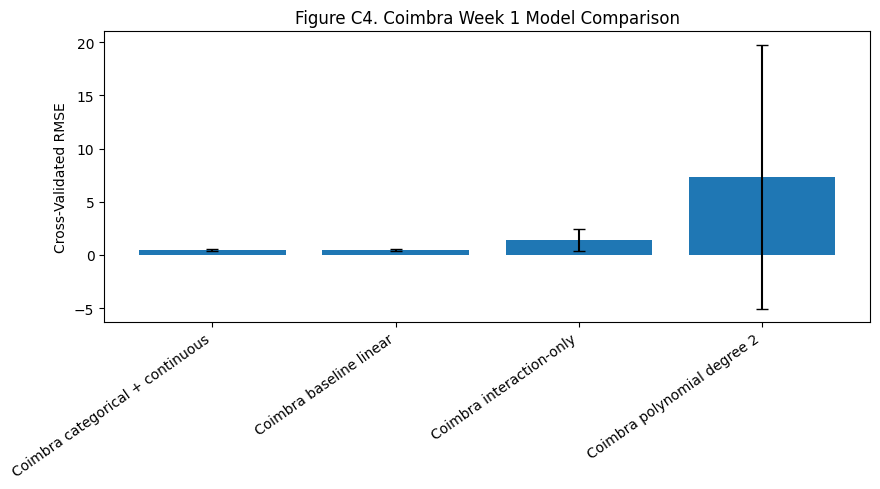

In [34]:
# Figure C4: Coimbra model comparison by cross-validated RMSE
plot_df = coimbra_cv_results_df.sort_values("CV_RMSE_mean")

plt.figure(figsize=(9, 5))
plt.bar(plot_df["model"], plot_df["CV_RMSE_mean"], yerr=plot_df["CV_RMSE_std"], capsize=4)
plt.ylabel("Cross-Validated RMSE")
plt.title("Figure C4. Coimbra Week 1 Model Comparison")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## Part 3 — Comparison and overall conclusions

### 3.1 Comparison: Wisconsin vs. Coimbra

With both datasets analyzed using the same Week 1 methods, I can compare two different types of breast cancer data.

The **Wisconsin dataset** uses tumor morphology measurements from images. These features directly describe the tumor itself, such as radius, area, perimeter, and concavity. Because the features are very directly connected to the tumor, I expect this dataset to have stronger predictive performance.

The **Coimbra dataset** uses clinical and blood-based measurements, such as BMI, glucose, insulin, HOMA, leptin, adiponectin, resistin, and MCP-1. These features may still be useful, but they are more indirect. They describe patient biomarkers rather than the tumor image itself.

From a modeling perspective, I expect the Wisconsin dataset to be easier to predict because the tumor features are closer to the diagnosis. The Coimbra dataset is still valuable because it shows how routine clinical and blood markers may also provide predictive information.

For Week 1 specifically, both datasets allowed me to practice:

- Linear regression as a linear probability model
- Polynomial terms
- Interaction terms
- Multicollinearity and VIF
- Categorical and continuous features
- Cross-validation for model comparison

The biggest difference is that multicollinearity in the Wisconsin dataset is mainly driven by tumor size variables, while multicollinearity in the Coimbra dataset may come from related clinical markers such as glucose, insulin, and HOMA.

### 3.2 Overall Week 1 conclusions

Across the two datasets, I found that the same modeling concepts can behave differently depending on the type of healthcare data. In the Wisconsin dataset, the strongest signal comes from tumor morphology features. Larger and more irregular tumors tend to be more associated with malignant diagnosis. In the Coimbra dataset, the predictors are more clinical and blood-based, so the connection to breast cancer status is less direct.

The Wisconsin dataset showed clear multicollinearity among size-related features such as radius, perimeter, and area. This made sense because these variables are all measuring tumor size in different ways. The Coimbra dataset also needed a multicollinearity check, especially because some biomarkers may be related to each other.

Polynomial and interaction terms were useful in both datasets because healthcare relationships may not always be simple straight lines. In Wisconsin, tumor size and concavity may work together. In Coimbra, blood markers such as glucose, insulin, and HOMA may interact with each other.

Overall, using both datasets makes the capstone stronger. The Wisconsin dataset helps answer how image-based tumor measurements relate to diagnosis, while the Coimbra dataset helps answer whether routine clinical and blood-based measurements can also support breast cancer prediction. This comparison gives the project more depth than using only one dataset.

## References

UCI Machine Learning Repository. (n.d.). *Breast Cancer Wisconsin (Diagnostic) dataset*. https://doi.org/10.24432/C5DW2B

Patrício, M., Pereira, J., Crisóstomo, J., Matafome, P., Seiça, R., & Caramelo, F. (2018). *Breast Cancer Coimbra* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52P59

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.